In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"F:/AI&ML/Day 14/Model Comparison & Best Model Selection/train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df = df.drop(["Name","Ticket","Cabin"], axis=1)
df["Age"].fillna(df["Age"].mean(), inplace=True)
df = pd.get_dummies(df, drop_first=True)

C:\Users\kurup\AppData\Local\Temp\ipykernel_10156\3064766190.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)


C:\Users\kurup\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
y_preds = {}

for name, model in models.items():
    y_preds[name] = model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, y_pred in y_preds.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)


           Model  Accuracy  Precision    Recall        F1
0       Logistic  0.776536   0.750000  0.689189  0.718310
1  Decision Tree  0.737430   0.680000  0.689189  0.684564
2  Random Forest  0.821229   0.808824  0.743243  0.774648
3            SVM  0.597765   0.666667  0.054054  0.100000


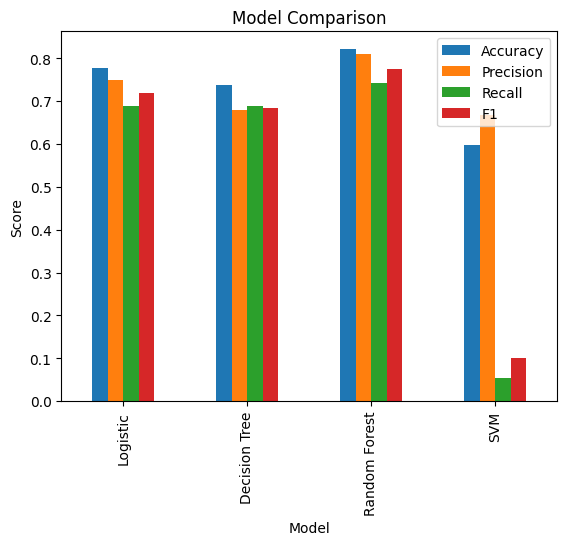

In [10]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model").plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()


In [11]:
for name, model in models.items():
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(name, train_acc, test_acc)


Logistic 0.7963483146067416 0.776536312849162
Decision Tree 1.0 0.7374301675977654
Random Forest 1.0 0.8212290502793296
SVM 0.6530898876404494 0.5977653631284916


In [12]:
import joblib

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_model.pkl")


['best_model.pkl']